# REDES NEURONALES RECURRENTES (RNN)

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import string
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Cargamos el dataset.

In [2]:
# Leemos el fichero
data = pd.read_csv('dataset.csv', sep=";", encoding='utf-8')
# Mostramos las 5 primeras filas
data.head()

,CONTENIDO A ANALIZAR,INTENSIDAD
0,cristina cifuentes podrí­a haber sido la presi...,3
1,habrí­a que reabrir el caso. el supremo se ded...,3
2,me parece un poco exagerado pedir más de tres ...,3
3,parece que todos los delincuentes niegan las e...,3
4,"preguntárselo al fracasado, media carrera en 6...",4


Cambiamos el nombre de las features para hacer su manejo más amigable:

In [3]:
data = data.rename(columns={'CONTENIDO A ANALIZAR': 'mensaje', 'INTENSIDAD': 'intensidad'})
data.head()

,mensaje,intensidad
0,cristina cifuentes podrí­a haber sido la presi...,3
1,habrí­a que reabrir el caso. el supremo se ded...,3
2,me parece un poco exagerado pedir más de tres ...,3
3,parece que todos los delincuentes niegan las e...,3
4,"preguntárselo al fracasado, media carrera en 6...",4


Mostramos información básica para saber a qué nos enfrentamos:

In [4]:
data.shape

(12279, 2)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12279 entries, 0 to 12278
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mensaje     12279 non-null  object
 1   intensidad  12279 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 192.0+ KB


Mostramos la distribución de mensajes de acuerdo a su intensidad. Problemas: hay un gran desbalanceo.

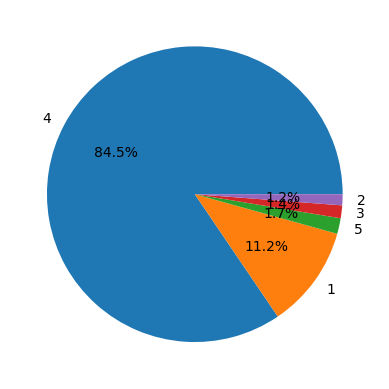

In [6]:
plt.pie(data['intensidad'].value_counts().values,
        labels = data['intensidad'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

Solo con minúsculas y quitamos los signos de puntuación de los mensajes

In [7]:
# Convertimos a minúsculas
data['mensaje'] = data['mensaje'].map(lambda x: x.lower())

# Función para eliminar signos de puntuación
def eliminar_signos(texto):
    return re.sub(f"[{re.escape(string.punctuation)}]", "", texto)

# Aplicamos la función al dataset
data['mensaje'] = data['mensaje'].map(eliminar_signos)
data.head()

,mensaje,intensidad
0,cristina cifuentes podrí­a haber sido la presi...,3
1,habrí­a que reabrir el caso el supremo se dedi...,3
2,me parece un poco exagerado pedir más de tres ...,3
3,parece que todos los delincuentes niegan las e...,3
4,preguntárselo al fracasado media carrera en 6 ...,4


Eliminamos las "stopwords".

In [8]:
# Obtenemos las stopwords en español
stop_words = set(stopwords.words('spanish'))
lemmatizer = WordNetLemmatizer()

# Definimos una función para eliminar stopwords y lematizar
def filtrar_palabras(texto):
    palabras_filtradas = []
    for palabra in texto.split():
        if palabra not in stop_words:
            palabra_lema = lemmatizer.lemmatize(palabra)
            palabras_filtradas.append(palabra_lema)
    return ' '.join(palabras_filtradas)

# Aplicamos la función
data['mensaje'] = data['mensaje'].apply(filtrar_palabras)
data.head()

,mensaje,intensidad
0,cristina cifuentes podrí­a haber sido presiden...,3
1,habrí­a reabrir caso supremo dedica proteger s...,3
2,parece exagerado pedir tres años prisión cifue...,3
3,parece delincuentes niegan evidencias pruebas ...,3
4,preguntárselo fracasado medium carrera 6 meses...,4


Creamos los conjuntos de entrenamiento y de test:

In [9]:
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# `sparse_categorical_crossentropy` espera que los valores de `y` sean enteros entre [0, num_classes–1].
# Dado que los valores de `intensidad` van de 1 a 5, usamos `LabelEncoder` para codificar los valores en el rango esperado.
le = LabelEncoder()
data['intensidad_enc'] = le.fit_transform(data['intensidad'])
num_classes = len(le.classes_)

X = data['mensaje']
#y = data['intensidad']
y = data['intensidad_enc']

# Dividimos el dataset en conjuntos de entrenamiento, validación y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Convertimos a numpy arrays
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

# Validación
X_valid = X_valid.values
y_valid = y_valid.values

# Creamos datasets de TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

In [10]:
# Hacemos sobremuestreo de la clase minoritaria
# Separamos por clase
dfs = {}
for cls in np.unique(y_train):
    dfs[cls] = data[data['intensidad_enc']==cls]

# Calculamos cuántos queremos de cada clase
max_count = max(len(d) for d in dfs.values())

# Reemplazamos
resampled = [
    dfs[cls].sample(max_count, replace=True, random_state=42)
    for cls in dfs
]
balanced_df = pd.concat(resampled).sample(frac=1, random_state=42)

# Reconstruimos X_train, y_train
X_train = balanced_df['mensaje'].values
y_train = balanced_df['intensidad_enc'].values

Mostramos un mensaje y su intensidad, simplemente para ver que todo va bien:

In [11]:
for men, inte in train_dataset.take(1):
  print('mensaje: ', men.numpy())
  print('nivel de odio: ', inte.numpy())

mensaje:  b'tanta paz lleves descanso dejas hdlgp'
nivel de odio:  3


Mezclamos los datos de forma aleatoria:

In [12]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

In [13]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [14]:
for men, inte in train_dataset.take(1):
  print('mensaje: ', men.numpy()[:3])
  print()
  print('nivel de odio: ', inte.numpy()[:3])

mensaje:  [b'pais sumisos'
 b'verg\xc3\xbcenza pa\xc3\xad\xc2\xadses mejor darlo menaspagar publicidad pseudogobiernoque presos vean tele gratis panfleto \xc2\xbfeh'
 b'verg\xc3\xbcenza entra\xc3\xb1as']

nivel de odio:  [0 0 3]


Definimos y configuramos un codificador de texto utilizando la capa TextVectorization

In [15]:
# Empezamos definiendo el tamaño del vocabulario
tamaño_vocabulario = 1000
max_len = 100

# Creamos una capa de vectorización de texto
vectorizador = tf.keras.layers.TextVectorization(
    max_tokens=tamaño_vocabulario,
    output_mode='int',
    output_sequence_length=max_len
)

# Se extraen solo los textos del conjunto de datos de entrenamiento
def extraer_texto(texto, etiqueta):
    return texto

# Adaptamos el vectorizador al texto del conjunto de datos de entrenamiento
dataset_texto = train_dataset.map(extraer_texto)
vectorizador.adapt(dataset_texto)

In [16]:
# Obtenemos el vocabulario aprendido por la capa de vectorización
vocabulario = np.array(vectorizador.get_vocabulary())

# Mostramos las primeras 20 palabras del vocabulario
primeras_20_palabras = vocabulario[:20]
primeras_20_palabras

array(['', '[UNK]', 'si', 'mierda', 'puta', 'asco', 'ser', 'gobierno',
       'panfleto', 'q', 'españa', 'paí\xads', 'gente', 'vergüenza',
       'gentuza', 'vaya', 'va', 'basura', 'solo', 'hacer'], dtype='<U18')


RNN para detectar el nivel de odio de un mensaje.

In [17]:
# Definición de EarlyStopping personalizado
tf.random.set_seed(42)
class CustomEarlyStopping(tf.keras.callbacks.EarlyStopping):
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        if self.model.stop_training:
            print(f"\nEntrenamiento detenido en la época {epoch+1} por early stopping (sin mejora en val_loss).")

early_stop = CustomEarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lrr = keras.callbacks.ReduceLROnPlateau(
                       monitor='val_accuracy',
                       factor=.01,
                       patience=3,
                       min_lr=1e-5)

In [18]:
from sklearn.metrics import confusion_matrix

# Función genérica para entrenar y evaluar un modelo
def train_and_evaluate(model,
                       optimizer = 'adam',
                       loss = 'sparse_categorical_crossentropy',
                       metrics = ['accuracy'],
                       epochs = 50,
                       batch_size = 128,
                       normalization = True,
                       verbose_level = 1,
                       callbacks=[early_stop, lrr],
                       class_weight=None):
    """
    Compila, entrena y evalúa un modelo de Keras.

    Parámetros:
        model: instancia de tf.keras.Model aún no compilada.

        optimizer: optimizador (objeto o string) para model.compile.
        loss: función de pérdida (objeto o string).
        metrics: lista de métricas para evaluar.
        epochs: número de épocas de entrenamiento.
        batch_size: tamaño del batch.
        normalization: se usan datos de entrada normalizados (True, False).
        callbacks: lista de callbacks a utilizar durante el entrenamiento.
        verbose_level: nivel de verbosidad.

    Retorna:
        history: objeto History de Keras tras el fit.
        test_loss: pérdida en el conjunto de prueba.
        test_acc: exactitud en el conjunto de prueba.
    """
    model.summary()
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=verbose_level
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=verbose_level)

    # Crear figura con 1 fila y 3 columnas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ----- Gráfico 1: Texto de precisión -----
    ax0 = axes[0]
    ax0.axis('off')
    ax0.text(
        0.5, 0.5,
        f'Precisión en test: {test_acc:.4f}',
        ha='center', va='center',
        fontsize=16
    )

    # ----- Gráfico 2: Accuracy y Loss -----
    ax1 = axes[1]
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epochs, history.history['accuracy'],     label='Accuracy entrenamiento')
    ax1.plot(epochs, history.history['val_accuracy'], label='Accuracy validación')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='upper left')

    # Loss (eje derecho)
    ax1b = ax1.twinx()
    ax1b.plot(epochs, history.history['loss'],       linestyle='--', label='Loss entrenamiento')
    ax1b.plot(epochs, history.history['val_loss'],   linestyle=':',  label='Loss validación')
    ax1b.set_ylabel('Loss')
    ax1b.legend(loc='upper right')

    ax1.set_title('Accuracy y Loss durante el entrenamiento')
    ax1.grid(True)

    # ----- Gráfico 3: Matriz de confusión -----
    ax2 = axes[2]
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    im = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
    ax2.set_title('Matriz de confusión')
    ax2.set_xlabel('Etiqueta Predicha')
    ax2.set_ylabel('Etiqueta Verdadera')
    fig.colorbar(im, ax=ax2)
    ax2.grid(False)

    # Ajustar layout para que no se solapen
    plt.tight_layout()
    plt.show()

    return history, test_loss, test_acc

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "rnn_odio"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_texto       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 100)       │          0 │ entrada_texto[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │    128,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 100)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 256)       │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa1 (Dense) │ (None, 128)       │     32,896 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ capa_densa1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa2 (Dense) │ (None, 64)        │      8,256 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 64)        │          0 │ capa_densa2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa3 (Dense) │ (None, 64)        │      4,160 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop3 (Dropout)     │ (None, 64)        │          0 │ capa_densa3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida (Dense)      │ (None, 5)         │        325 │ drop3[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 437,317 (1.67 MB)

 Trainable params: 437,061 (1.67 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6080 - loss: 0.9372 - val_accuracy: 0.7146 - val_loss: 0.6685 - learning_rate: 0.0010
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8946 - loss: 0.2894 - val_accuracy: 0.7818 - val_loss: 0.5002 - learning_rate: 0.0010
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9161 - loss: 0.2233 - val_accuracy: 0.8481 - val_loss: 0.4233 - learning_rate: 0.0010
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9290 - loss: 0.1901 - val_accuracy: 0.8612 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9344 - loss: 0.1767 - val_accuracy: 0.8669 - val_loss: 0.4144 - learning_rate: 0.0010
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9390 - loss: 0.1589 - val_accuracy: 0.8844 - val_loss: 0.3573 - learning_rate: 0.0010
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9402 - loss: 

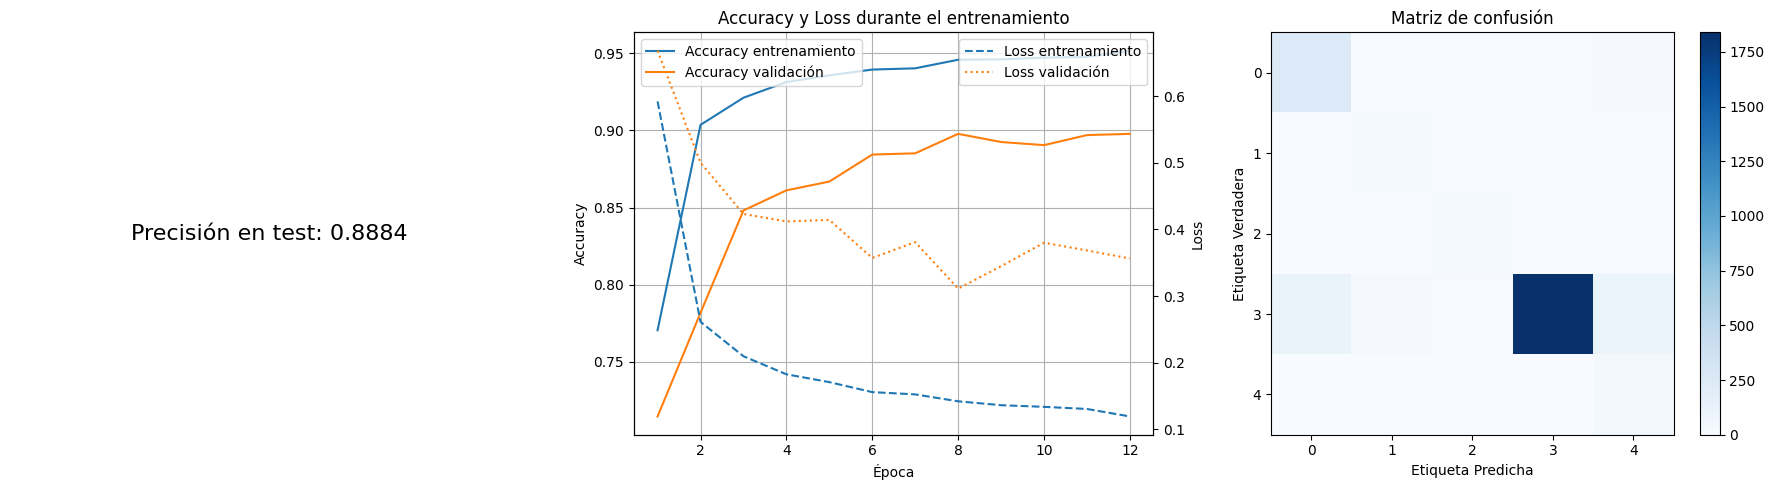

In [21]:
from tensorflow.keras import Input, Model
from tensorflow.keras import datasets, models, regularizers
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from sklearn.utils.class_weight import compute_class_weight

num_classes = len(np.unique(y_train))

inputs = Input(shape=(), dtype=tf.string, name='entrada_texto')

x = vectorizador(inputs)

x = Embedding(input_dim=tamaño_vocabulario,
              output_dim=128,
              input_length=max_len,
              mask_zero=True,
              name='embedding')(x)

# Long Short-Term Memory bidireccional
# procesa la secuencia de embeddings hacia adelante y hace atrás
x = Bidirectional(LSTM(128), name='bilstm')(x)

x = Dense(128, activation='relu', name='capa_densa1')(x)
x = BatchNormalization(name='batch_normalization')(x)
x = Dropout(0.5, name='drop1')(x)
x = Dense(64, activation='relu', name='capa_densa2')(x)
x = Dropout(0.2, name='drop2')(x)
x = Dense(64, activation='relu', name='capa_densa3')(x)
x = Dropout(0.2, name='drop3')(x)

outputs = Dense(num_classes, activation='softmax', name='salida')(x)

modelo = Model(inputs, outputs, name='rnn_odio')

clases = np.unique(y_train)
pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases,
    y=y_train
)
class_weight = dict(zip(clases, pesos))

history, test_loss, test_acc = train_and_evaluate(modelo, class_weight=class_weight)

## Diseño de la RNN

La red neuronal recurrente se construye siguiendo el siguiente esquema:

1. **Entrada y vectorización**  
   - Se define una capa de entrada `Input(shape=(), dtype=tf.string)` que acepta cadenas de texto crudo.  
   - A continuación, un `TextVectorization` previamente adaptado se encarga de tokenizar, truncar y codificar cada mensaje como una secuencia de índices enteros de longitud fija (`max_len`).

2. **Embedding**  
   - Tras la tokenización, una capa `Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True)` transforma cada índice en un vector de 128 dimensiones.  
   - El parámetro `mask_zero=True` indica al modelo que ignore las posiciones de padding.  
   - El embedding aprende representaciones densas de palabras, capturando similitudes semánticas y reduciendo la dimensionalidad de entrada.

3. **LSTM bidireccional**  
   - Se utiliza `Bidirectional(LSTM(128))` para procesar la secuencia tanto de izquierda a derecha como de derecha a izquierda.  
   - Así, se tiene en cuenta el contexto anterior y posterior a cada token, ya que en tareas de detección de odio o sentimiento esto puede alterar su carga emocional.

4. **Capas densas y normalización**  
   - Se apilan tres bloques densos:
     1. `Dense(128, activation='relu')` + `BatchNormalization` + `Dropout(0.5)`  
     2. `Dense(64,  activation='relu')` + `Dropout(0.2)`  
     3. `Dense(64,  activation='relu')` + `Dropout(0.2)`
    - **BatchNormalization** estabiliza y acelera el entrenamiento normalizando las activaciones.  
    - Los **Dropout** (50 % en la primera capa, 20 % en las siguientes) impiden el sobreajuste, lo cual es importante cuando el dataset está limitado o desequilibrado.
    - La progresiva reducción de tamaño (128 → 64 → 64) permite concentrar la información más relevante en dimensiones cada vez más pequeñas.

5. **Capa de salida**  
   - Finalmente, un `Dense(num_classes, activation='softmax')` emite una distribución de probabilidad sobre las categorías de intensidad de odio (por ejemplo: muy bajo, bajo, medio, alto, muy alto).  
   - La entropía cruzada (`sparse_categorical_crossentropy`) junto con softmax es una configuración estándar y estable para clasificación multiclase.

6. **Entrenamiento y callbacks**  
   - Se compila con optimizador Adam, `loss='sparse_categorical_crossentropy'` y métrica de precisión.  
   - Se emplean dos callbacks clave:
     - **EarlyStopping**: detiene el entrenamiento cuando `val_loss` deja de mejorar tras N épocas, restaurando los mejores pesos.  
     - **ReduceLROnPlateau**: reduce la tasa de aprendizaje si la precisión de validación se estanca, ajustando finamente la convergencia.  
   - De esta forma evitamos rener que hacer un ajuste manual exhaustivo de hiperparámetros y se reduce el riesgo de sobreajuste.


Dado que el dataset está desbalanceado, hemos hecho un sobremuestreo (oversampling) de la clase minoritaria, es decir, repetir ejemplos de la clase más rara para darle más visibilidad al modelo. Además, se han usado pesos para las clases.

````
compute_class_weight(
    class_weight='balanced',
    classes=clases,
    y=y_train
)
````

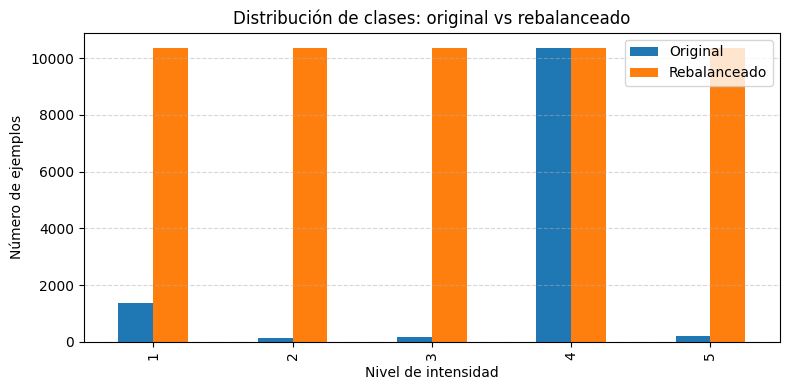

In [22]:
# Distribución original
orig = data['intensidad_enc'].value_counts().sort_index()
orig.index = le.inverse_transform(orig.index)

# Distribución rebalanceada
new = balanced_df['intensidad_enc'].value_counts().sort_index()
new.index = le.inverse_transform(new.index)

comp = pd.concat([orig, new], axis=1)
comp.columns = ['Original', 'Rebalanceado']

comp.plot.bar(figsize=(8,4))
plt.title("Distribución de clases: original vs rebalanceado")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Número de ejemplos")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()